In [19]:
import boto3
import geopandas as gpd
from shapely import Polygon
import rasterio
from botocore.config import Config
from botocore import UNSIGNED
import numpy as np

In [4]:
EGYPT_MIN_X = 24.703159612459785
EGYPT_MAX_X = 36.944131811662686

EGYPT_MIN_Y = 21.981232860710175
EGYPT_MAX_Y = 31.63498313922825


In [5]:
def hrslGrid():
  polys = []
  for lat in range(-90, 90, 10):
    for lon in range(-180, 180, 10):
      ll = [lon, lat]
      ul = [lon, lat+10]
      ur = [lon+10, lat+10]
      lr = [lon+10, lat]
      corners = [ll,ul,ur,lr]
      poly = Polygon([p for p in corners])
      polys.append(poly)
  d = {'geometry':polys}
  gdf = gpd.GeoDataFrame(d, crs="EPSG:4326")
  return gdf

In [6]:
grid = hrslGrid()

In [28]:
qisms_gdf = gpd.GeoDataFrame.from_file("/home/mohamed/Mohamed/Vodafone_project/all_egypt_map_shpfile/shp_output_names/Governerates/Governerates.shp")

In [39]:
geom = qisms_gdf["geometry"][0]

In [40]:
qisms_gdf.iloc[0,:]

OBJECTID                                                      1
GOV_CODE                                                     17
SHAPE_Leng                                        367595.547268
SHAPE_Area                                    2291259108.819944
GOV_NAME_E                                 Menoufia Governorate
GOV_NAME_A                                      محافظة المنوفية
geometry      POLYGON ((30.938108467264907 30.74502737511619...
Name: 0, dtype: object

In [91]:
qisms_gdf.centroid

/tmp/ipykernel_7814/3215094653.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  qisms_gdf.centroid


0     POINT (30.88293 30.46427)
1     POINT (31.63612 27.33522)
2     POINT (29.73557 30.84814)
3     POINT (32.32281 30.54349)
4     POINT (34.15707 24.68560)
5     POINT (30.26845 30.62418)
6     POINT (29.51229 28.85261)
7     POINT (31.55296 31.12679)
8     POINT (32.22970 29.65647)
9     POINT (31.72831 30.66338)
10    POINT (30.58180 29.32526)
11    POINT (31.58350 29.98144)
12    POINT (31.27845 30.30208)
13    POINT (30.57805 28.08964)
14    POINT (28.39752 24.80213)
15    POINT (31.07126 28.82106)
16    POINT (32.28304 31.11067)
17    POINT (33.79476 29.02642)
18    POINT (31.74622 31.38067)
19    POINT (32.12566 26.66972)
20    POINT (33.73818 30.42941)
21    POINT (32.91313 25.97986)
22    POINT (26.96959 29.69264)
23    POINT (32.58550 23.32314)
24    POINT (30.90230 31.29751)
25    POINT (31.04546 30.88588)
26    POINT (32.68397 25.63984)
dtype: geometry

In [5]:
import geopandas as gpd
import geonamescache
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
from numpy.random import choice
import random
import datetime
from shapely import Point
from datetime import datetime, timedelta

import warnings
import matplotlib.pyplot as plt


In [91]:
df = pd.read_csv("/home/mohamed/Mohamed/Vodafone_project/projects/app/visualization/qisms_clusters_dir/counts_4.csv", )

In [92]:
df


,Unnamed: 0,time,count
0,0,2010-01-01 00:00:00,0
1,1,2010-01-01 00:15:00,0
2,2,2010-01-01 00:30:00,0
3,3,2010-01-01 00:45:00,0
4,4,2010-01-01 01:00:00,0
...,...,...,...
525595,525595,2024-12-30 22:45:00,0
525596,525596,2024-12-30 23:00:00,0
525597,525597,2024-12-30 23:15:00,0
525598,525598,2024-12-30 23:30:00,0


In [93]:
df["time"] = pd.to_datetime(df["time"])


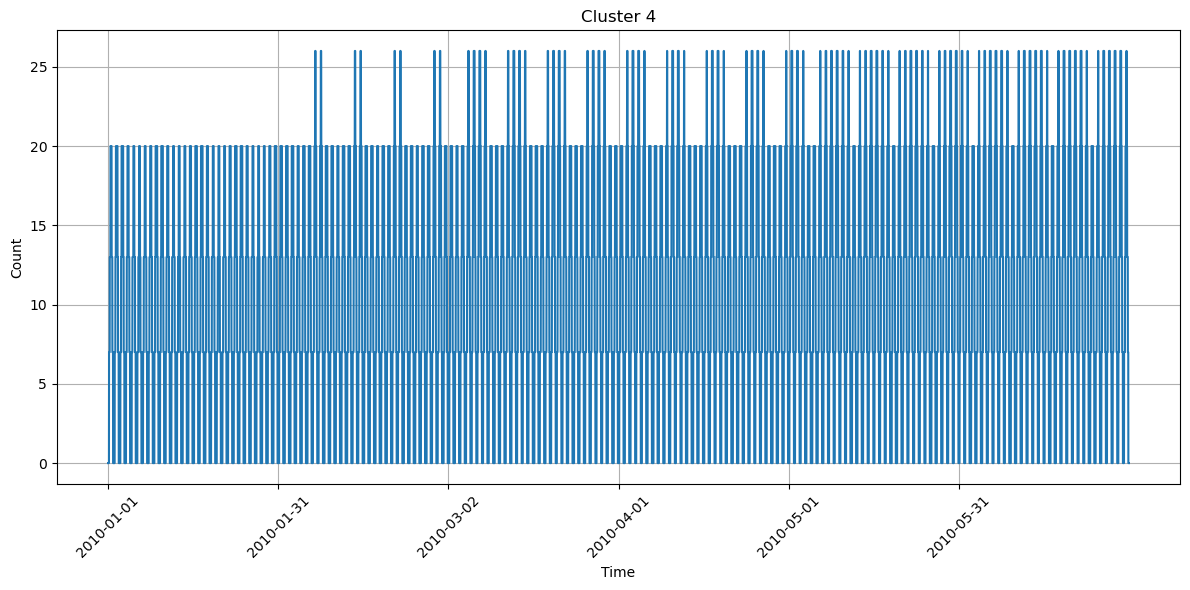

In [95]:
plt.figure(figsize=(12, 6))
plt.plot(df['time'][:96*30*6], df['count'][:96*30*6], linestyle='-')

# Specify x-ticks manually
plt.xticks(df['time'][:96*30*6:96*30], rotation=45)

# Add titles and labels
plt.title('Cluster 4')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()

In [76]:
df

,Unnamed: 0,time,count
0,0,2010-01-01 00:00:00,0
1,1,2010-01-01 00:15:00,0
2,2,2010-01-01 00:30:00,0
3,3,2010-01-01 00:45:00,0
4,4,2010-01-01 01:00:00,14
...,...,...,...
525595,525595,2024-12-30 22:45:00,15
525596,525596,2024-12-30 23:00:00,0
525597,525597,2024-12-30 23:15:00,0
525598,525598,2024-12-30 23:30:00,0
